<a href="https://colab.research.google.com/github/DanielPrados/Simulacion-de-un-PAS/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de gráficas asociadas a un PAS

El paseo aleatorio simple de parámetro $p$ (PAS) es un proceso estocástico que se evalúa en $\mathbb{N}$ y toma valores en $\mathbb{Z}$. Para cada $t\in \mathbb{N}$ se considera: $$X_t=\sum_{s=1}^t Z_s$$
donde $\{Z_s\}_{s\in \mathbb{N}}$ son variables aleatorias independientes e idénticamente distribuidas según la siguiente distribución: $$P(Z_s=1)=p, \; P(Z_s=-1)=1-p.$$




Nuestro objetivo es poder generar gráficas que contengan múltiples trayectorias asociadas a un PAS. Para esto nos ayudaremos de numpy y matplotlib.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

En primer lugar vamos a definir una función que nos ayudará a simular trayectorias de un PAS para cierta probabilidad y un número de pasos concreto:

In [ ]:
def simular_PAS(p,n,reps):
  '''
  Input:
  p: Es el valor que toma la probabilidad, indica la probabilidad de que en cada paso
  el PAS tome el valor 1, mientras que (1-p) es la probabilidad de que tome el valor -1.
  n:  Indica el número de pasos que se van a realizar en el PAS.
  reps: Indica el número de trayectorias que se van a simular.
  Output:
  output: Devuelve un array de dimensión (reps,n) con los valores del PAS en cada paso
  para cada trayectoria.
 '''
  probabilidades = [p,1-p]
  opciones = [1,-1]
  pasos = np.random.choice(opciones, size = (reps,n), p = probabilidades) # shape: (reps,n)
  output = np.cumsum(pasos, axis = 1)

  return output #shape:(reps, n)


A continuación vamos a generar las gráficas correspondientes utilizando el submódulo pyplot de matplotlib.

## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

En primer lugar generamos la gráfica del PAS para $p=0.5$.

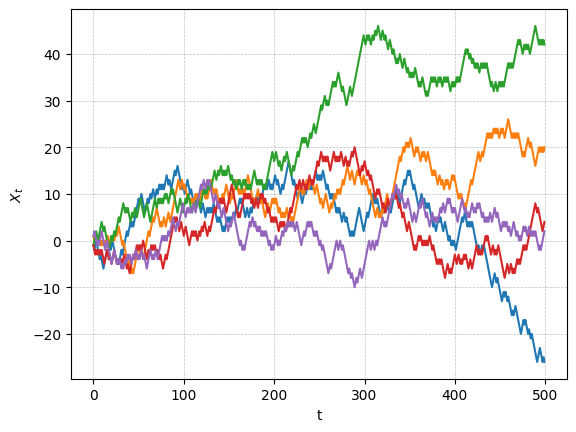

In [ ]:
matriz_pas = simular_PAS(0.5,500,5)
#La función plt.plot genera la gráfica por columnas con lo que trasponemos la matriz
#para que la gráfica sea correcta.
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.show()

A continuación, cambiamos la probabilidad a $p=0.6$.

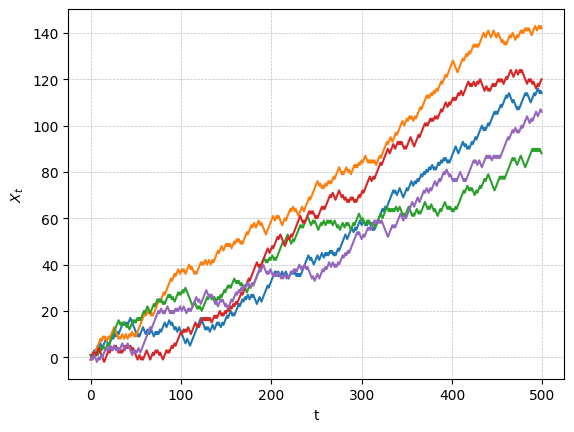

In [ ]:
matriz_pas = simular_PAS(0.6,500,5)
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.show()

Por último, observamos que ocurre para $p=0.4$.

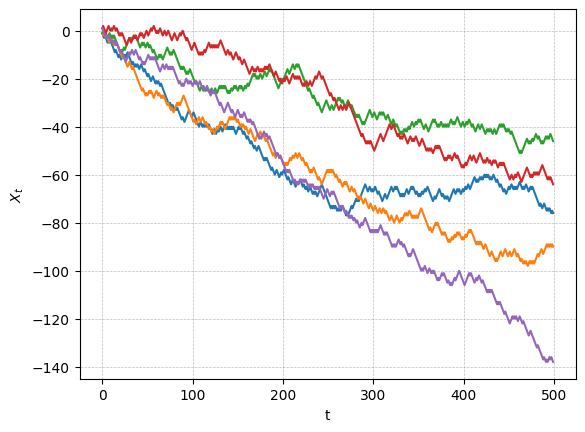

In [ ]:
matriz_pas = simular_PAS(0.4,500,5)
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.show()

## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Ahora vamos a pasar a generar tomando otras probabilidades distintas el mismo tipo de gráfica añadiendo una región sombreada en función de la media y la desviación típica teóricas. Además, añadiremos la representación de la media teórica asociada a cada caso. Concretamente representaremos las gráficas para $p=0.5$, $p=0.75$ y $p=0.95$.

En primer lugar empezamos con $p=0.5$.

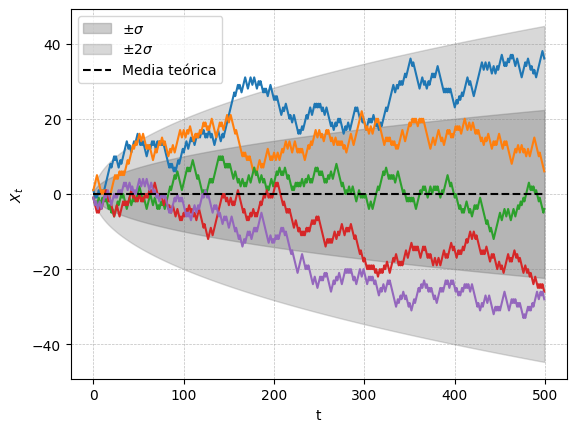

In [ ]:
p = 0.5
n = 500
matriz_pas = simular_PAS(p,n,5)
#Generamos un vector con todos los pasos para a partir de este vector definir
#la media y  la desviación típica en cada paso.
x = np.arange(500)
media = (2*p-1)*x
desv_tip = np.sqrt(4*p*(1-p)*x)
limsup = media+desv_tip
liminf = media-desv_tip
limsup2 = media+2*desv_tip
liminf2 = media-2*desv_tip
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
#Para generar la región sombreada correspondiente a la desviación típica y a dos veces
#esta usamos plt.fill_between().
plt.fill_between(x,limsup,liminf, color = 'grey', alpha = 0.4, label = r'$\pm \sigma$')
plt.fill_between(x,limsup2,liminf2, color =  'grey', alpha = 0.3, label = r'$\pm 2\sigma$')
plt.plot(media, color = 'black', linestyle = '--', linewidth = 1.5,alpha = 1, label = 'Media teórica')
plt.legend()
plt.show()


Generamos ahora la gráfica para $p=0.75$.

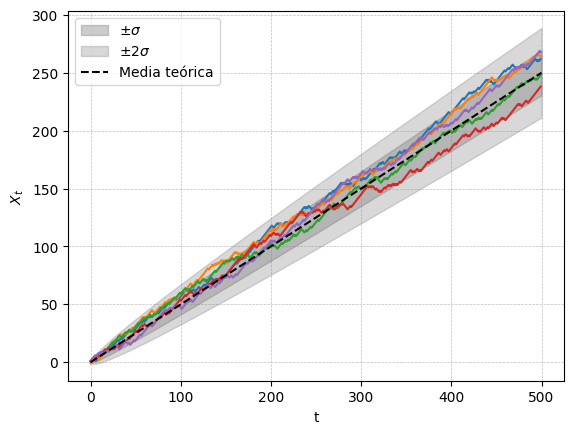

In [ ]:
p = 0.75
n = 500
matriz_pas = simular_PAS(p,n,5)
x = np.arange(501)
media = (2*p-1)*x
desv_tip = np.sqrt(4*p*(1-p)*x)
limsup = media+desv_tip
liminf = media-desv_tip
limsup2 = media+2*desv_tip
liminf2 = media-2*desv_tip
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.fill_between(x,limsup,liminf, color = 'grey', alpha = 0.4, label = r'$\pm \sigma$')
plt.fill_between(x,limsup2,liminf2, color =  'grey', alpha = 0.3, label = r'$\pm 2\sigma$')
plt.plot(media, color = 'black', linestyle = '--', linewidth = 1.5,alpha = 1, label = 'Media teórica')
plt.legend()
plt.show()

Por último veamos el caso de $p=0.95$.

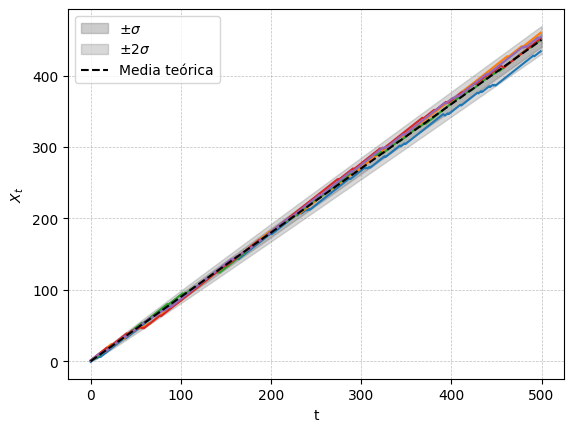

In [ ]:
p = 0.95
n = 500
matriz_pas = simular_PAS(p,n,5)
x = np.arange(501)
media  = (2*p-1)*x
desv_tip = np.sqrt(4*p*(1-p)*x)
limsup = media+desv_tip
liminf = media-desv_tip
limsup2 = media+2*desv_tip
liminf2 = media-2*desv_tip
plt.plot(np.transpose(matriz_pas))
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.fill_between(x,limsup,liminf, color = 'grey', alpha = 0.4, label = r'$\pm \sigma$')
plt.fill_between(x,limsup2,liminf2, color =  'grey', alpha = 0.3, label = r'$\pm 2\sigma$')
plt.plot(media, color = 'black', linestyle = '--', linewidth = 1.5,alpha = 1, label = 'Media teórica')
plt.legend()
plt.show()

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Por último, haremos una gráfica en la que se pueda observar la media empírica al promediar varias trayectorias del PAS. Concretamente promediaremos 5, 100, 200, 500 y 1000 trayectorias. Además, se representará la media teórica del PAS

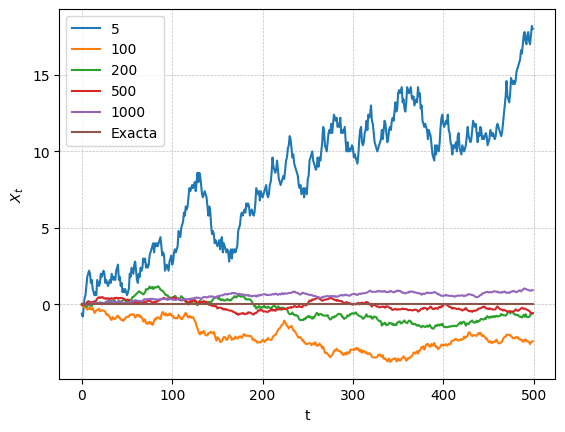

In [ ]:
p=0.5
n=500
matriz_pas1 = simular_PAS(p,n,5)
matriz_pas2 = simular_PAS(p,n,100)
matriz_pas3 = simular_PAS(p,n,200)
matriz_pas4 = simular_PAS(p,n,500)
matriz_pas5 = simular_PAS(p,n,1000)
media1=np.mean(matriz_pas1,axis = 0)
media2=np.mean(matriz_pas2,axis = 0)
media3=np.mean(matriz_pas3,axis = 0)
media4=np.mean(matriz_pas4,axis = 0)
media5=np.mean(matriz_pas5,axis = 0)
x = np.arange(500)
mediateorica = (2*p-1)*x
#Generamos una matriz con las medias de cada uno de los casos, para esto usamos
#np.column_stack que agrupa los arrays correspondientes a las medias por columnas.
matrizmedias = np.column_stack((media1,media2,media3,media4,media5,mediateorica))
nombres = ['5', '100', '200', '500', '1000', 'Exacta']
#Al usar la función previa no hace falta trasponer la matriz dado que ya tenemos los
#arrays agrupados  por columnas.
plt.plot(matrizmedias, label = nombres)
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5, alpha = 0.5)
plt.legend()
plt.show()